In [1]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector
from PIL import Image

%matplotlib widget

In [2]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB18_3n1.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [31]:
channel = 1
time = 20
img, img_disp = get_frame(czi,time,channel)

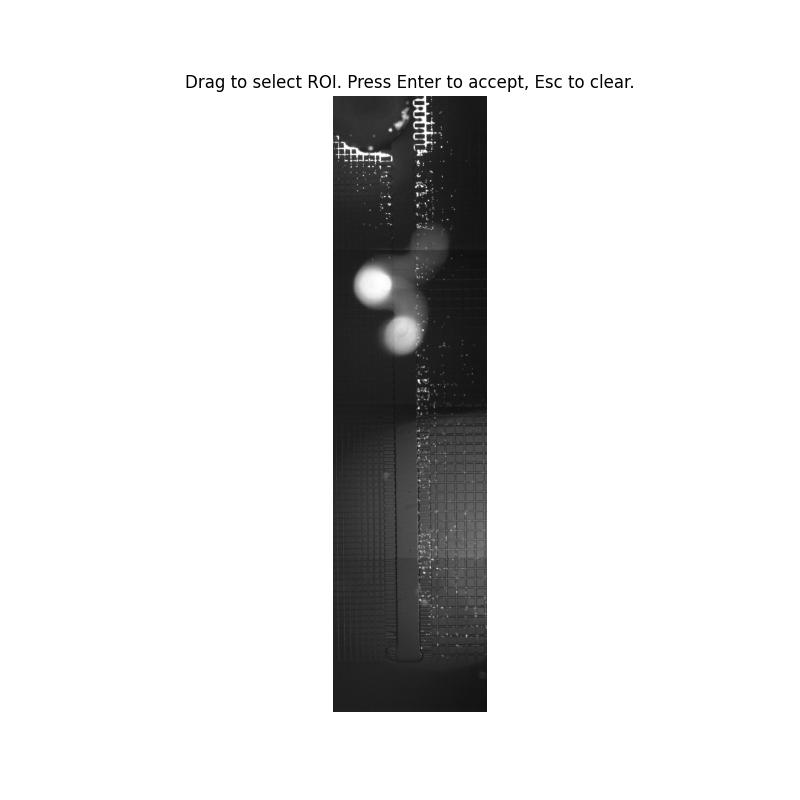

In [32]:
roi = ROI_selector(img)

In [9]:
roi = {'x0': 1098.2012987012986,
 'y0': 6078.980519480519,
 'x1': 1816.0194805194806,
 'y1': 6987.24025974026}

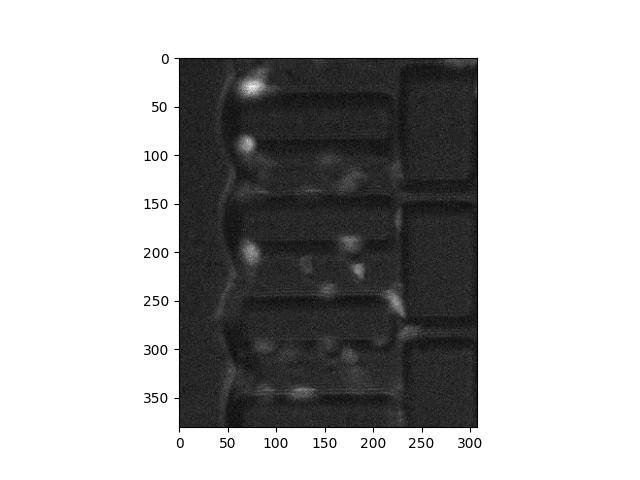

In [69]:

stretch_min = 93
stretch_max = 99.5
channel = 1
time = 20
img, img_disp = get_frame(czi,time,channel,roi=roi,gamma=1,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(img,cmap="gray")

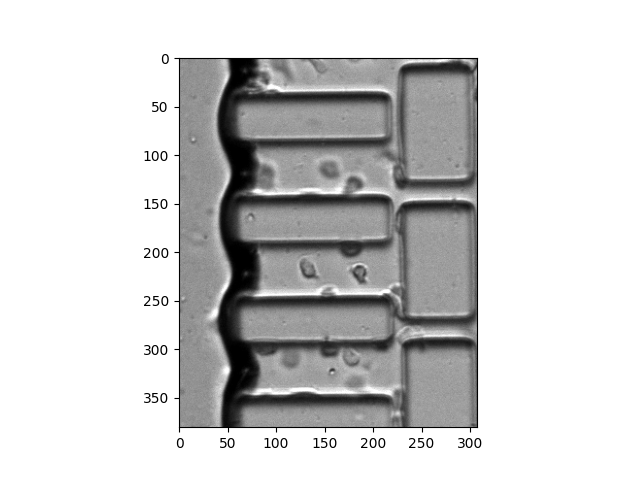

In [70]:

stretch_min = 1
stretch_max = 99.5
channel = 2
time = 20
img, img_disp = get_frame(czi,time,channel,roi=roi,gamma=1,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(img_disp,cmap="gray")

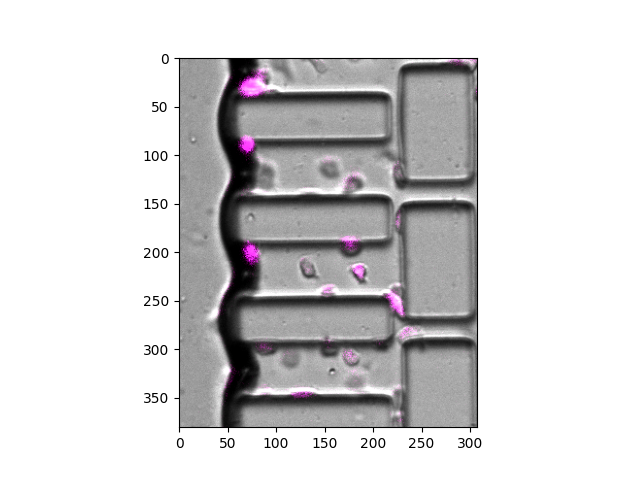

In [71]:
stretch_min = 93
stretch_max = 99.5
_, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi,    stretch_min = stretch_min, stretch_max = stretch_max)
_, ch_gray    = get_frame(czi, time, 2, gamma=1, roi=roi)

ch_magenta = norm(ch_magenta)
ch_gray    = norm(ch_gray)

rgb_magenta = mcherry(ch_magenta)[..., :3]
rgb_gray    = gray_cmap(ch_gray)[..., :3]
merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)
fig,ax = plt.subplots()
ax.imshow(merged)

In [76]:
from math import sqrt
from skimage import data
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.color import rgb2gray

import matplotlib.pyplot as plt


stretch_min = 93
stretch_max = 99.5
channel = 1
time = 20
img, img_disp = get_frame(czi,time,channel,roi=roi,gamma=1,stretch_min=stretch_min,stretch_max=stretch_max)
img = img.astype(float)
from skimage import exposure
img = exposure.rescale_intensity(img, in_range='image', out_range=(0,1))
img = (img - img.mean()) / img.std()

image_gray = img

blobs_doh = blob_log(image_gray, min_sigma=5, max_sigma=20, num_sigma=10, threshold=0.8)

# # Compute radii in the 3rd column.
# blobs_log[:, 2] = blobs_log[:, 2] * sqrt(2)

# blobs_dog = blob_dog(image_gray, max_sigma=30, threshold=0.1)
# blobs_dog[:, 2] = blobs_dog[:, 2] * sqrt(2)

# blobs_doh = blob_doh(image_gray,min_sigma=5, max_sigma=20, threshold=100)



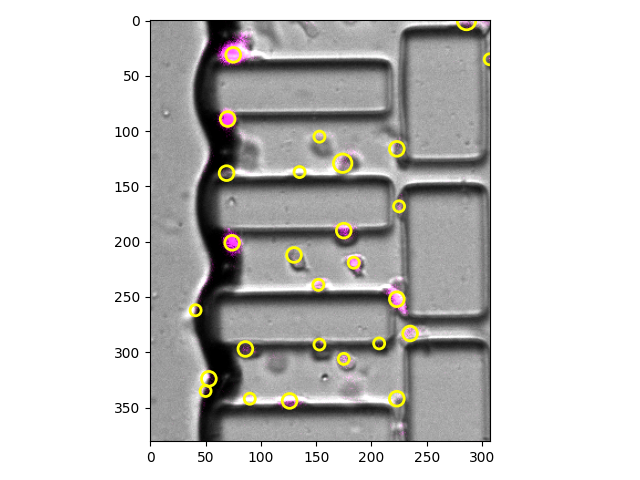

In [77]:

blobs_list = [blobs_doh]
colors = ['yellow',]
titles = ['Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)
fig, ax = plt.subplots()

ax.imshow(merged)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color="yellow", linewidth=2, fill=False)
    ax.add_patch(c)

plt.tight_layout()
plt.show()